In [1]:
from pao.io import parse_pao_file, PaoFile
from pathlib import Path
import numpy as np
from numpy.linalg import vector_norm
import math
from glob import glob
import matplotlib.pyplot as plt

In [2]:
def yzx2xyz(yzx):
    assert yzx.size == 3
    return np.array([yzx[2], yzx[0], yzx[1]])

In [3]:
def angle(v1, v2):
    return math.degrees(math.acos(np.dot(v1, v2) / (vector_norm(v1) * vector_norm(v2))))

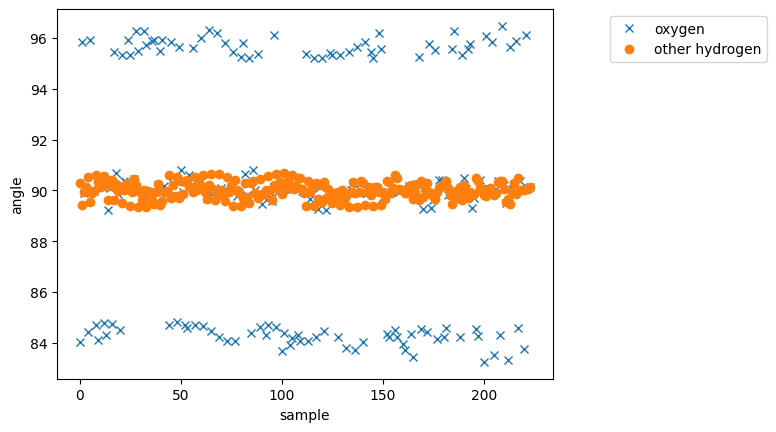

In [4]:
angles_oxygen = []
angles_hydrogen = []

for fn in sorted(glob("../../../pao_ml_equivar/2H2O_rotations/*/2H2O_pao42-1_0.pao")):
    #print(fn)
    f = parse_pao_file(Path(fn))
    assert f.kinds["H"].prim_basis_name == "DZVP-MOLOPT-GTH"
    
    for iatom, ikind in enumerate(f.atom2kind):
        imol = int(iatom /3)
        pos = f.coords[iatom]
        xblock = f.xblocks[iatom]
        if ikind == "H":
            oxygen = imol * 3
            other_hydrogen = iatom + 1 if iatom-3*imol == 1 else iatom-1
            vec_oxygen =  f.coords[iatom] -  f.coords[oxygen]
            vec_other_h =  f.coords[iatom] -  f.coords[other_hydrogen]
            for ipao in range(xblock.shape[0]):
                if ipao == 1: # for some reason the second pao function is always p-dominated
                    
                    vec_p = yzx2xyz(xblock[ipao][2:5]) # p-shell of DZVP-MOLOPT-GTH for Hydrogen
                    angles_oxygen.append(angle(vec_p, vec_oxygen))
                    angles_hydrogen.append( angle(vec_p, vec_other_h))

                
plt.plot(angles_oxygen, 'x', label="oxygen")
plt.plot(angles_hydrogen, 'o', label="other hydrogen")
plt.ylabel("angle")
plt.xlabel("sample")
plt.legend(bbox_to_anchor=(1.1, 1.0))